# Analyse Complète de la Base de Données Ekwo

Ce notebook analyse **uniquement les fichiers Excel** présents dans le dossier `ekwo_db`, explore les relations entre les différentes tables et génère des visualisations pour mieux comprendre la structure et les patterns des données.

In [37]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Patch pour corriger le bug openpyxl avec 'biltinId'
# Ce bug se produit dans les fichiers Excel qui ont une faute de frappe dans les styles
try:
    from openpyxl.styles.named_styles import NamedCellStyle
    import types
    
    # Sauvegarder la méthode originale
    _original_init = NamedCellStyle.__init__
    
    # Créer une nouvelle méthode qui corrige le bug
    def _patched_init(self, name, biltinId=None, builtinId=None, **kwargs):
        # Si biltinId est fourni (bug), le convertir en builtinId
        if biltinId is not None and builtinId is None:
            builtinId = biltinId
        # Appeler la méthode originale avec builtinId
        return _original_init(self, name, builtinId=builtinId, **kwargs)
    
    # Appliquer le patch
    NamedCellStyle.__init__ = _patched_init
    print("Patch openpyxl appliqué pour corriger le bug 'biltinId'")
except Exception as e:
    print(f"Impossible d'appliquer le patch openpyxl: {e}")

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Configuration pour l'affichage des DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("Bibliothèques importées avec succès")

Impossible d'appliquer le patch openpyxl: cannot import name 'NamedCellStyle' from 'openpyxl.styles.named_styles' (C:\Users\manil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\openpyxl\styles\named_styles.py)
Bibliothèques importées avec succès


## 1. Chargement des Données

Nous allons charger tous les fichiers Excel disponibles dans le dossier `ekwo_db`.

In [38]:
# Définition du chemin vers le dossier ekwo_db
base_path = Path('ekwo_db')

# Liste de tous les fichiers Excel à charger
excel_files = {
    'audiofile': 'audiofile.xlsx',
    'categorie_audio': 'categorie_audio.xlsx',
    'categorie_entrainement': 'categorie_entrainement.xlsx',
    'description_entrainement': 'description_entrainement.xlsx',
    'description_first_time': 'description_first_time.xlsx',
    'entrainement': 'entrainement.xlsx',
    'entrainement_audio': 'entrainement_audio.xlsx',
    'etape_entrainement': 'etape_entrainement.xlsx',
    'materiel': 'materiel.xlsx',
    'materiel_entrainement': 'materiel_entrainement.xlsx',
    'medical': 'medical.xlsx',
    'pro1': 'pro1.xlsx',
    'pro2': 'pro2.xlsx',
    'pro3': 'pro3.xlsx',
    'pro4': 'pro4.xlsx',
    'type_entrainement': 'type_entrainement.xlsx',
    'type_pro1': 'type_pro1.xlsx',
    'type_pro2': 'type_pro2.xlsx',
    'type_pro3': 'type_pro3.xlsx'
}

# Dictionnaire pour stocker tous les DataFrames
dataframes = {}

# Fonction pour charger un fichier Excel avec plusieurs méthodes de secours
def load_excel_file(file_path, name):
    """Charge un fichier Excel en essayant plusieurs méthodes pour contourner les erreurs de style"""
    
    # Méthode 1: Essayer avec pandas/openpyxl normalement
    try:
        df = pd.read_excel(file_path, engine='openpyxl')
        return df, None
    except Exception as e1:
        # Méthode 2: Utiliser xlrd si disponible (pour les fichiers .xls)
        try:
            df = pd.read_excel(file_path, engine='xlrd')
            return df, None
        except:
            pass
        
        # Méthode 3: Utiliser openpyxl avec gestion d'erreur au niveau XML
        try:
            from openpyxl import load_workbook
            import xml.etree.ElementTree as ET
            
            # Essayer de charger en ignorant les styles
            # On va utiliser keep_vba=False et data_only=True
            wb = load_workbook(file_path, data_only=True, keep_vba=False)
            ws = wb.active
            
            # Convertir en DataFrame manuellement
            data = []
            for row in ws.iter_rows(values_only=True):
                data.append(row)
            
            wb.close()
            
            if data and len(data) > 0:
                # Première ligne comme header
                if len(data) > 1:
                    df = pd.DataFrame(data[1:], columns=data[0])
                else:
                    df = pd.DataFrame(columns=data[0])
                return df, None
            else:
                return None, "Fichier vide"
                
        except Exception as e2:
            # Méthode 4: Utiliser pyexcel si disponible
            try:
                import pyexcel
                records = pyexcel.get_records(file_name=str(file_path))
                if records:
                    df = pd.DataFrame(records)
                    return df, None
            except:
                pass
            
            # Méthode 5: Corriger le fichier XML avant de le charger
            # Cette méthode corrige le bug 'biltinId' dans le fichier styles.xml
            try:
                import zipfile
                import tempfile
                import shutil
                
                # Créer un fichier temporaire
                tmp_file = tempfile.NamedTemporaryFile(delete=False, suffix='.xlsx')
                tmp_file.close()
                
                # Copier le fichier original
                shutil.copy2(file_path, tmp_file.name)
                
                # Ouvrir le fichier Excel comme un ZIP
                temp_dir = tempfile.mkdtemp()
                try:
                    with zipfile.ZipFile(tmp_file.name, 'r') as zip_ref:
                        zip_ref.extractall(temp_dir)
                    
                    # Corriger le fichier styles.xml
                    styles_xml = os.path.join(temp_dir, 'xl', 'styles.xml')
                    if os.path.exists(styles_xml):
                        # Lire et corriger le fichier styles.xml
                        with open(styles_xml, 'r', encoding='utf-8') as f:
                            content = f.read()
                        # Remplacer biltinId par builtinId
                        content = content.replace('biltinId', 'builtinId')
                        with open(styles_xml, 'w', encoding='utf-8') as f:
                            f.write(content)
                    
                    # Recompresser le fichier
                    with zipfile.ZipFile(tmp_file.name, 'w', zipfile.ZIP_DEFLATED) as zip_out:
                        for root, dirs, files in os.walk(temp_dir):
                            for file in files:
                                file_path_full = os.path.join(root, file)
                                arcname = os.path.relpath(file_path_full, temp_dir)
                                zip_out.write(file_path_full, arcname)
                    
                    # Maintenant charger le fichier corrigé
                    wb = load_workbook(tmp_file.name, data_only=True)
                    ws = wb.active
                    data = []
                    for row in ws.iter_rows(values_only=True):
                        data.append(row)
                    wb.close()
                    
                    if data and len(data) > 0:
                        if len(data) > 1:
                            df = pd.DataFrame(data[1:], columns=data[0])
                        else:
                            df = pd.DataFrame(columns=data[0])
                        return df, None
                finally:
                    # Nettoyer les fichiers temporaires
                    try:
                        shutil.rmtree(temp_dir)
                        os.unlink(tmp_file.name)
                    except:
                        pass
                        
            except Exception as e3:
                return None, f"Toutes les méthodes ont échoué. Dernière erreur: {str(e3)[:150]}"

# Chargement de tous les fichiers Excel
print("Chargement des fichiers Excel...")
print("="*80)

for name, filename in excel_files.items():
    file_path = base_path / filename
    if not file_path.exists():
        print(f"⚠️  {filename} non trouvé")
        continue
    
    df, error = load_excel_file(file_path, name)
    if df is not None:
        dataframes[name] = df
        print(f"{name}: {len(df)} lignes, {len(df.columns)} colonnes")
    else:
        print(f"Erreur lors du chargement de {filename}")
        if error:
            print(f"   Détails: {error[:100]}...")

print(f"\nTotal de {len(dataframes)} tables chargées avec succès sur {len(excel_files)} fichiers")

Chargement des fichiers Excel...
audiofile: 190 lignes, 5 colonnes
categorie_audio: 6 lignes, 3 colonnes
categorie_entrainement: 7 lignes, 5 colonnes
description_entrainement: 811 lignes, 8 colonnes
description_first_time: 70 lignes, 8 colonnes
entrainement: 80 lignes, 15 colonnes
entrainement_audio: 7902 lignes, 7 colonnes
etape_entrainement: 273 lignes, 5 colonnes
materiel: 25 lignes, 4 colonnes
materiel_entrainement: 689 lignes, 6 colonnes
medical: 8 lignes, 4 colonnes
pro1: 8196 lignes, 14 colonnes
pro2: 240 lignes, 14 colonnes
pro3: 1505 lignes, 16 colonnes
pro4: 1484 lignes, 16 colonnes
type_entrainement: 4 lignes, 4 colonnes
type_pro1: 7 lignes, 3 colonnes
type_pro2: 1 lignes, 3 colonnes
type_pro3: 1 lignes, 3 colonnes

Total de 19 tables chargées avec succès sur 19 fichiers


## 2. Préparation des Données et Création des Mappings

Avant d'analyser les données, nous créons des dictionnaires de correspondance pour mapper les IDs aux noms réels. Cela nous permettra d'afficher des informations compréhensibles dans tous nos graphiques et analyses au lieu de simples numéros d'identification.

In [39]:
# Création des dictionnaires de mapping ID -> Nom pour améliorer la lisibilité des analyses

print("PRÉPARATION DES DONNÉES - Création des mappings ID -> Nom")
print("="*80)

# Mapping Matériel ID -> Nom
materiel_map = {}
if 'materiel' in dataframes:
    df_materiel = dataframes['materiel']
    if 'MaterielID' in df_materiel.columns and 'Name' in df_materiel.columns:
        materiel_map = dict(zip(df_materiel['MaterielID'], df_materiel['Name']))
        print(f"Mapping Matériel créé: {len(materiel_map)} matériels")
    else:
        print("Colonnes MaterielID ou Name non trouvées dans la table materiel")

# Mapping AudioFile ID -> Titre
audiofile_map = {}
if 'audiofile' in dataframes:
    df_audio = dataframes['audiofile']
    if 'AudioFileID' in df_audio.columns and 'Title' in df_audio.columns:
        audiofile_map = dict(zip(df_audio['AudioFileID'], df_audio['Title']))
        print(f"Mapping AudioFile créé: {len(audiofile_map)} fichiers audio")
    else:
        print("Colonnes AudioFileID ou Title non trouvées dans la table audiofile")

# Mapping Catégorie Entrainement ID -> Nom
categorie_entrainement_map = {}
if 'categorie_entrainement' in dataframes:
    df_cat = dataframes['categorie_entrainement']
    if 'CategorieEntrainementID' in df_cat.columns and 'CategorieEntrainement' in df_cat.columns:
        categorie_entrainement_map = dict(zip(df_cat['CategorieEntrainementID'], 
                                               df_cat['CategorieEntrainement']))
        print(f"Mapping Catégorie Entrainement créé: {len(categorie_entrainement_map)} catégories")
    else:
        print("Colonnes CategorieEntrainementID ou CategorieEntrainement non trouvées")

# Mapping Catégorie Audio ID -> Libellé
categorie_audio_map = {}
if 'categorie_audio' in dataframes:
    df_cat_audio = dataframes['categorie_audio']
    if 'CatAudioID' in df_cat_audio.columns and 'LibCat' in df_cat_audio.columns:
        categorie_audio_map = dict(zip(df_cat_audio['CatAudioID'], df_cat_audio['LibCat']))
        print(f"Mapping Catégorie Audio créé: {len(categorie_audio_map)} catégories audio")
    else:
        print("Colonnes CatAudioID ou LibCat non trouvées")

# Mapping Entrainement ID -> Nom
entrainement_map = {}
if 'entrainement' in dataframes:
    df_ent = dataframes['entrainement']
    if 'EntrainementID' in df_ent.columns and 'Nom' in df_ent.columns:
        entrainement_map = dict(zip(df_ent['EntrainementID'], df_ent['Nom']))
        print(f"Mapping Entrainement créé: {len(entrainement_map)} entraînements")
    else:
        print("Colonnes EntrainementID ou Nom non trouvées")

# Mapping Type Entrainement ID -> Type
type_entrainement_map = {}
if 'type_entrainement' in dataframes:
    df_type = dataframes['type_entrainement']
    if 'TypeEntrainementID' in df_type.columns and 'TypeEntrainement' in df_type.columns:
        type_entrainement_map = dict(zip(df_type['TypeEntrainementID'], df_type['TypeEntrainement']))
        print(f"Mapping Type Entrainement créé: {len(type_entrainement_map)} types")
    else:
        print("Colonnes TypeEntrainementID ou TypeEntrainement non trouvées")

print(f"\nTous les mappings ont été créés avec succès!")
print(f"   - {len(materiel_map)} matériels")
print(f"   - {len(audiofile_map)} fichiers audio")
print(f"   - {len(categorie_entrainement_map)} catégories d'entraînement")
print(f"   - {len(categorie_audio_map)} catégories audio")
print(f"   - {len(entrainement_map)} entraînements")
print(f"   - {len(type_entrainement_map)} types d'entraînement")

PRÉPARATION DES DONNÉES - Création des mappings ID -> Nom
Mapping Matériel créé: 25 matériels
Mapping AudioFile créé: 190 fichiers audio
Mapping Catégorie Entrainement créé: 7 catégories
Mapping Catégorie Audio créé: 6 catégories audio
Mapping Entrainement créé: 80 entraînements
Mapping Type Entrainement créé: 4 types

Tous les mappings ont été créés avec succès!
   - 25 matériels
   - 190 fichiers audio
   - 7 catégories d'entraînement
   - 6 catégories audio
   - 80 entraînements
   - 4 types d'entraînement


## 2. Vue d'Ensemble des Données

Explorons la structure de chaque table pour comprendre les données disponibles.

In [40]:
# Affichage d'un résumé de toutes les tables
summary_data = []
for name, df in dataframes.items():
    summary_data.append({
        'Table': name,
        'Lignes': len(df),
        'Colonnes': len(df.columns),
        'Colonnes': ', '.join(df.columns.tolist()[:5]) + ('...' if len(df.columns) > 5 else '')
    })

summary_df = pd.DataFrame(summary_data)
print("Résumé des tables disponibles:")
print(summary_df.to_string(index=False))

Résumé des tables disponibles:
                   Table  Lignes                                                                           Colonnes
               audiofile     190                                      N° Enr., AudioFileID, Data, Title, CatAudioID
         categorie_audio       6                                                        N° Enr., CatAudioID, LibCat
  categorie_entrainement       7 N° Enr., CategorieEntrainementID, CategorieEntrainement, TypeEntrainementID, Photo
description_entrainement     811                N° Enr., DescEntrainementID, EtapeEntrainementID, OrdreNum, Type...
  description_first_time      70               N° Enr., DescFirstTimeID, CategorieEntrainementID, OrdreNum, Type...
            entrainement      80               N° Enr., EntrainementID, CategorieEntrainementID, Nom, Difficulte...
      entrainement_audio    7902                   N° Enr., Entrainement_AudioID, AudioFileID, Pausetime, bPause...
      etape_entrainement     273         

In [41]:
# Correctif global pour éviter les erreurs .str sur les colonnes de descriptions
print("Correctif: conversion des colonnes textuelles en 'string' pour les tables de descriptions")

desc_tables = ['description_entrainement', 'description_first_time']
for t in desc_tables:
    if t in dataframes:
        df = dataframes[t]
        candidates = [c for c in df.columns if any(k in c.lower() for k in ['texte','text','titre','title','type','desc'])]
        for c in candidates:
            try:
                dataframes[t][c] = df[c].astype('string')
            except Exception:
                pass
print("Conversion terminée (là où applicable)")

Correctif: conversion des colonnes textuelles en 'string' pour les tables de descriptions
Conversion terminée (là où applicable)


In [42]:
# Affichage des premières lignes de chaque table
for name, df in dataframes.items():
    print(f"\n{'='*80}")
    print(f"Table: {name.upper()}")
    print(f"{'='*80}")
    print(f"Shape: {df.shape}")
    print(f"\nColonnes: {list(df.columns)}")
    print(f"\nPremières lignes:")
    display(df.head())
    print(f"\nTypes de données:")
    print(df.dtypes)
    print(f"\nValeurs manquantes:")
    print(df.isnull().sum())


Table: AUDIOFILE
Shape: (190, 5)

Colonnes: ['N° Enr.', 'AudioFileID', 'Data', 'Title', 'CatAudioID']

Premières lignes:


,N° Enr.,AudioFileID,Data,Title,CatAudioID
0,1,2,None,Changer de main,4
1,2,3,None,Départ au galop,4
2,3,4,None,Départ au trot,4
3,4,5,None,Enelever les enrenements,6
4,5,6,None,Fin de séance,7



Types de données:
N° Enr.         int64
AudioFileID     int64
Data           object
Title          object
CatAudioID      int64
dtype: object

Valeurs manquantes:
N° Enr.          0
AudioFileID      0
Data           190
Title            0
CatAudioID       0
dtype: int64

Table: CATEGORIE_AUDIO
Shape: (6, 3)

Colonnes: ['N° Enr.', 'CatAudioID', 'LibCat']

Premières lignes:


,N° Enr.,CatAudioID,LibCat
0,1,2,CSO
1,2,3,DRESSAGE
2,3,4,GENERAL
3,4,5,LR
4,5,6,LONGE



Types de données:
N° Enr.        int64
CatAudioID     int64
LibCat        object
dtype: object

Valeurs manquantes:
N° Enr.       0
CatAudioID    0
LibCat        0
dtype: int64

Table: CATEGORIE_ENTRAINEMENT
Shape: (7, 5)

Colonnes: ['N° Enr.', 'CategorieEntrainementID', 'CategorieEntrainement', 'TypeEntrainementID', 'Photo']

Premières lignes:


...


Types de données:
N° Enr.       int64
TypeProID     int64
Type         object
dtype: object

Valeurs manquantes:
N° Enr.      0
TypeProID    0
Type         0
dtype: int64

Table: TYPE_PRO2
Shape: (1, 3)

Colonnes: ['N° Enr.', 'TypeProID', 'Type']

Premières lignes:


,N° Enr.,TypeProID,Type
0,1,1,Vétérinaires Equins



Types de données:
N° Enr.       int64
TypeProID     int64
Type         object
dtype: object

Valeurs manquantes:
N° Enr.      0
TypeProID    0
Type         0
dtype: int64

Table: TYPE_PRO3
Shape: (1, 3)

Colonnes: ['N° Enr.', 'TypeProID', 'Type']

Premières lignes:


,N° Enr.,TypeProID,Type
0,1,1,Ecuries de propriétaires



Types de données:
N° Enr.       int64
TypeProID     int64
Type         object
dtype: object

Valeurs manquantes:
N° Enr.      0
TypeProID    0
Type         0
dtype: int64


## 3. Analyse des Tables Principales

### 3.1 Analyse de la Table Audiofile

In [43]:
if 'audiofile' in dataframes:
    df_audio = dataframes['audiofile']
    print("ANALYSE DE LA TABLE AUDIOFILE")
    print("="*80)
    print(f"Nombre total d'enregistrements audio: {len(df_audio)}")
    print(f"\nColonnes disponibles: {list(df_audio.columns)}")
    print(f"\nStatistiques descriptives:")
    print(df_audio.describe())
    
    display(df_audio.head(10))

ANALYSE DE LA TABLE AUDIOFILE
Nombre total d'enregistrements audio: 190

Colonnes disponibles: ['N° Enr.', 'AudioFileID', 'Data', 'Title', 'CatAudioID']

Statistiques descriptives:
          N° Enr.  AudioFileID  CatAudioID
count  190.000000   190.000000  190.000000
mean    95.500000    96.500000    3.510526
std     54.992424    54.992424    1.409490
min      1.000000     2.000000    0.000000
25%     48.250000    49.250000    3.000000
50%     95.500000    96.500000    3.000000
75%    142.750000   143.750000    4.000000
max    190.000000   191.000000    7.000000


,N° Enr.,AudioFileID,Data,Title,CatAudioID
0,1,2,None,Changer de main,4
1,2,3,None,Départ au galop,4
2,3,4,None,Départ au trot,4
3,4,5,None,Enelever les enrenements,6
4,5,6,None,Fin de séance,7
5,6,7,None,Galoper à main D,4
6,7,8,None,Galoper à main G,4
7,8,9,None,marcher au pas à main D,4
8,9,10,None,Marcher au pas à main G,4
9,10,11,None,Marcher au pas,4


### 3.2 Analyse de la Table Entrainement

ANALYSE DE LA TABLE ENTRAINEMENT
Nombre total d'entraînements: 80

Colonnes disponibles: ['N° Enr.', 'EntrainementID', 'CategorieEntrainementID', 'Nom', 'Difficulte', 'Duree', 'TempsPrep', 'TempsMiseEnPlace', 'TempsEchauffement', 'TempsTravail', 'TempsRecuperation', 'TempsSoins', 'Photo', 'IndiceEntrainement', 'Free']

Statistiques des colonnes numériques:
         N° Enr.  EntrainementID  CategorieEntrainementID  Difficulte  \
count  80.000000       80.000000                80.000000   80.000000   
mean   42.612500       42.612500                 7.937500    1.250000   
std    23.413452       23.413452                 4.393159    1.152872   
min     3.000000        3.000000                 1.000000    0.000000   
25%    22.750000       22.750000                 5.000000    0.000000   
50%    42.500000       42.500000                 7.000000    1.000000   
75%    62.250000       62.250000                13.000000    2.000000   
max    83.000000       83.000000                15.000000

,N° Enr.,EntrainementID,CategorieEntrainementID,Nom,Difficulte,Duree,TempsPrep,TempsMiseEnPlace,TempsEchauffement,TempsTravail,TempsRecuperation,TempsSoins,Photo,IndiceEntrainement,Free
0,3,3,5,Départs au galop,1,01:28:00,15,0,23,20,10,20,None,Les indications de temps sont données à titre ...,0
1,4,4,5,Transitions au trot et au pas,1,01:30:00,15,5,20,20,10,20,None,L'exercice nécessite l'utilisation de 6 barres...,0
2,5,5,5,Serpentine (3B) au trot,1,01:30:00,15,10,20,20,10,20,None,L'exercice nécessite 3 cônes et 4 barres\nLes ...,0
3,6,6,5,Serpentine (3B) au galop/Contre galop,3,01:30:00,15,10,20,20,10,20,None,Les indications de temps sont données à titre ...,0
4,7,7,5,Serpentine (3B) au galop/changement de pieds,3,01:30:00,15,10,20,20,10,20,None,L'exercice nécessite 4 barres et 3 cônes\nLes ...,0
5,8,8,5,Serpentine (4B) au trot,1,01:30:00,15,10,20,20,10,20,None,L'exercice nécessite 4 cônes\nLes indications ...,0
6,9,9,5,Serpentine (4B) au galop/contre galop,2,01:30:00,15,5,20,20,10,20,None,L'exercice nécessite 4 cônes\nLes indications ...,0
7,10,10,5,Serpentine (4B) au galop/changement de pieds,3,01:20:00,15,5,20,20,10,20,None,L'exercice nécessite 4 cônes\nLes indications ...,0
8,11,11,5,Epaule en dedans au pas,1,01:25:00,15,0,20,20,10,20,None,Les indications de temps sont données à titre ...,0
9,12,12,5,Epaule en dedans au trot,2,01:25:00,15,0,20,20,10,20,None,Les indications de temps sont données à titre ...,0



Distribution de la difficulté:
Difficulte
0    30
1    15
2    20
3    15
Name: count, dtype: int64


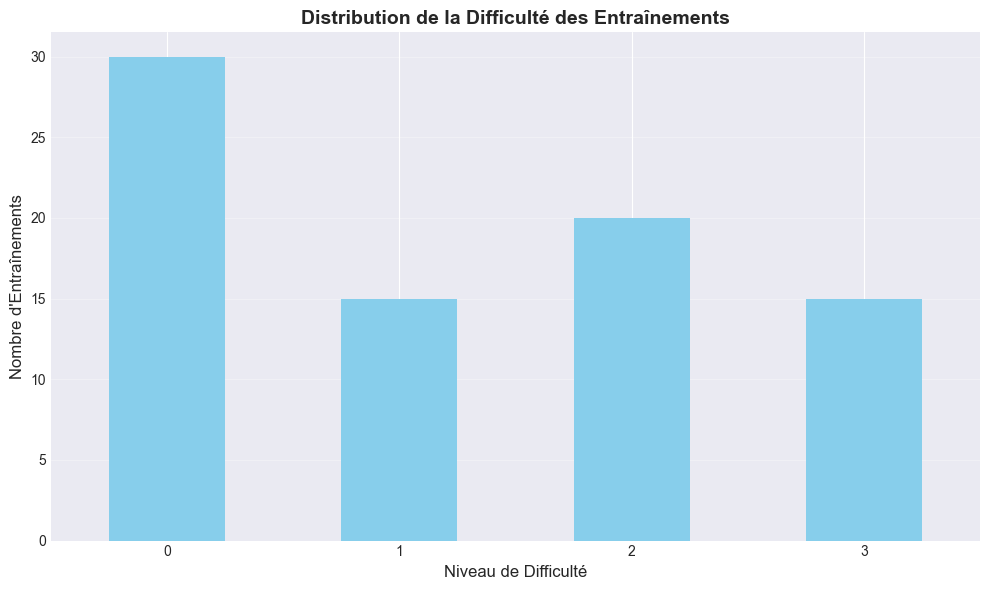

In [44]:
if 'entrainement' in dataframes:
    df_entrainement = dataframes['entrainement']
    print("ANALYSE DE LA TABLE ENTRAINEMENT")
    print("="*80)
    print(f"Nombre total d'entraînements: {len(df_entrainement)}")
    print(f"\nColonnes disponibles: {list(df_entrainement.columns)}")
    
    # Analyse des colonnes numériques si elles existent
    numeric_cols = df_entrainement.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        print(f"\nStatistiques des colonnes numériques:")
        print(df_entrainement[numeric_cols].describe())
    
    display(df_entrainement.head(10))
    
    # Analyse de la difficulté si la colonne existe
    if 'Difficulte' in df_entrainement.columns:
        print(f"\nDistribution de la difficulté:")
        print(df_entrainement['Difficulte'].value_counts().sort_index())
        
        # Graphique de la distribution de la difficulté
        plt.figure(figsize=(10, 6))
        df_entrainement['Difficulte'].value_counts().sort_index().plot(kind='bar', color='skyblue')
        plt.title('Distribution de la Difficulté des Entraînements', fontsize=14, fontweight='bold')
        plt.xlabel('Niveau de Difficulté', fontsize=12)
        plt.ylabel('Nombre d\'Entraînements', fontsize=12)
        plt.xticks(rotation=0)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

### Explications — Distribution de la difficulté

- Ce barplot montre le **nombre d’entraînements** par niveau de difficulté.
- Objectif : vérifier l’équilibre de l’offre (ex : éviter trop d’exercices concentrés sur un seul niveau).
- Un pic indique le niveau de difficulté le plus fréquent dans la base.

### 3.3 Analyse de la Table Catégorie Entrainement

ANALYSE DE LA TABLE CATEGORIE ENTRAINEMENT
Nombre total de catégories: 7

Colonnes disponibles: ['N° Enr.', 'CategorieEntrainementID', 'CategorieEntrainement', 'TypeEntrainementID', 'Photo']


,N° Enr.,CategorieEntrainementID,CategorieEntrainement,TypeEntrainementID,Photo
0,1,1,EN LONGE,1,None
1,2,5,DRESSAGE,2,None
2,4,9,CSO,3,None
3,5,12,Trotting,10,None
4,6,13,LONGUES-RÊNES,1,None
5,7,15,Ethologie,1,None
6,8,16,None,0,None


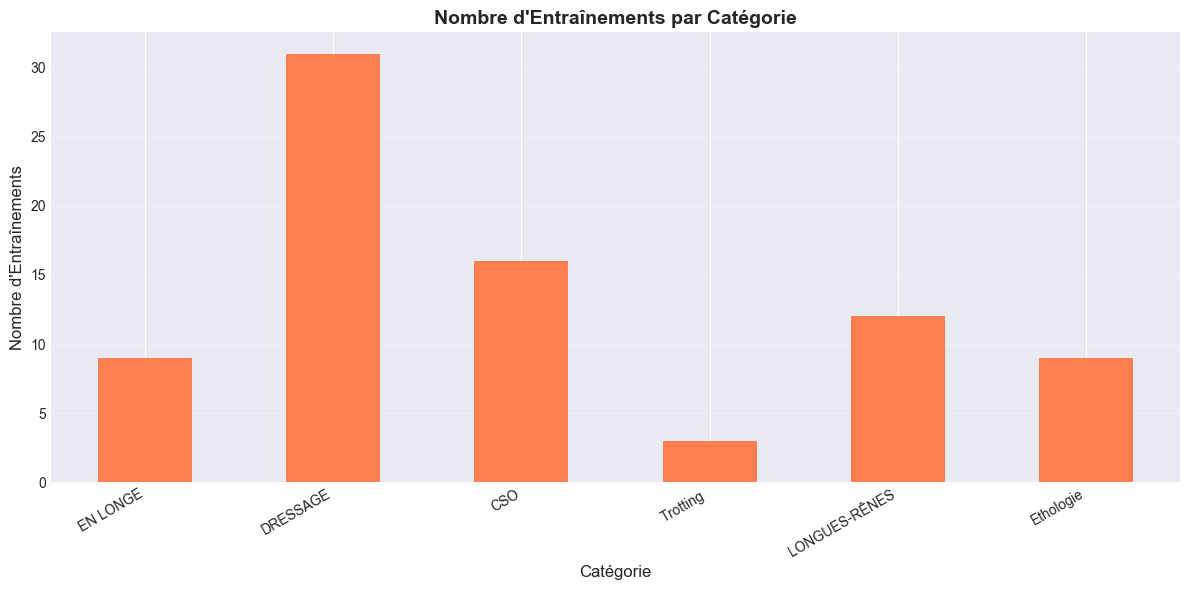

In [45]:
if 'categorie_entrainement' in dataframes:
    df_cat_entrainement = dataframes['categorie_entrainement']
    print("ANALYSE DE LA TABLE CATEGORIE ENTRAINEMENT")
    print("="*80)
    print(f"Nombre total de catégories: {len(df_cat_entrainement)}")
    print(f"\nColonnes disponibles: {list(df_cat_entrainement.columns)}")
    display(df_cat_entrainement)
    
    # Graphique des catégories si on a des données
    if len(df_cat_entrainement) > 0:
        # Compter les entraînements par catégorie si on peut faire la jointure
        if 'entrainement' in dataframes:
            df_ent = dataframes['entrainement']
            if 'CategorieEntrainementID' in df_ent.columns:
                cat_counts = df_ent['CategorieEntrainementID'].value_counts().sort_index()

                cat_counts_named = cat_counts.rename(
                    index=lambda x: categorie_entrainement_map.get(x, f"Catégorie {x}")
                )
                
                plt.figure(figsize=(12, 6))
                cat_counts_named.plot(kind='bar', color='coral')
                plt.title("Nombre d'Entraînements par Catégorie", fontsize=14, fontweight='bold')
                plt.xlabel('Catégorie', fontsize=12)
                plt.ylabel("Nombre d'Entraînements", fontsize=12)
                plt.xticks(rotation=30, ha='right')
                plt.grid(axis='y', alpha=0.3)
                plt.tight_layout()
                plt.show()

### Explications — Nombre d’entraînements par catégorie

- Ce graphique montre combien d’entraînements appartiennent à chaque **catégorie**.
- Les étiquettes de l’axe X utilisent les **noms** (mapping `CategorieEntrainementID` → libellé), pour une lecture directe côté entreprise.
- À utiliser pour identifier des catégories sur-représentées (offre très large) ou sous-représentées (opportunité d’enrichissement).

## 4. Analyse des Relations entre les Tables

Explorons les relations entre les différentes tables pour comprendre la structure de la base de données.

RELATION ENTRE ENTRAINEMENT ET ETAPE ENTRAINEMENT
Nombre d'entraînements avec étapes: 80
Nombre moyen d'étapes par entraînement: 3.41
Nombre min d'étapes: 1
Nombre max d'étapes: 4


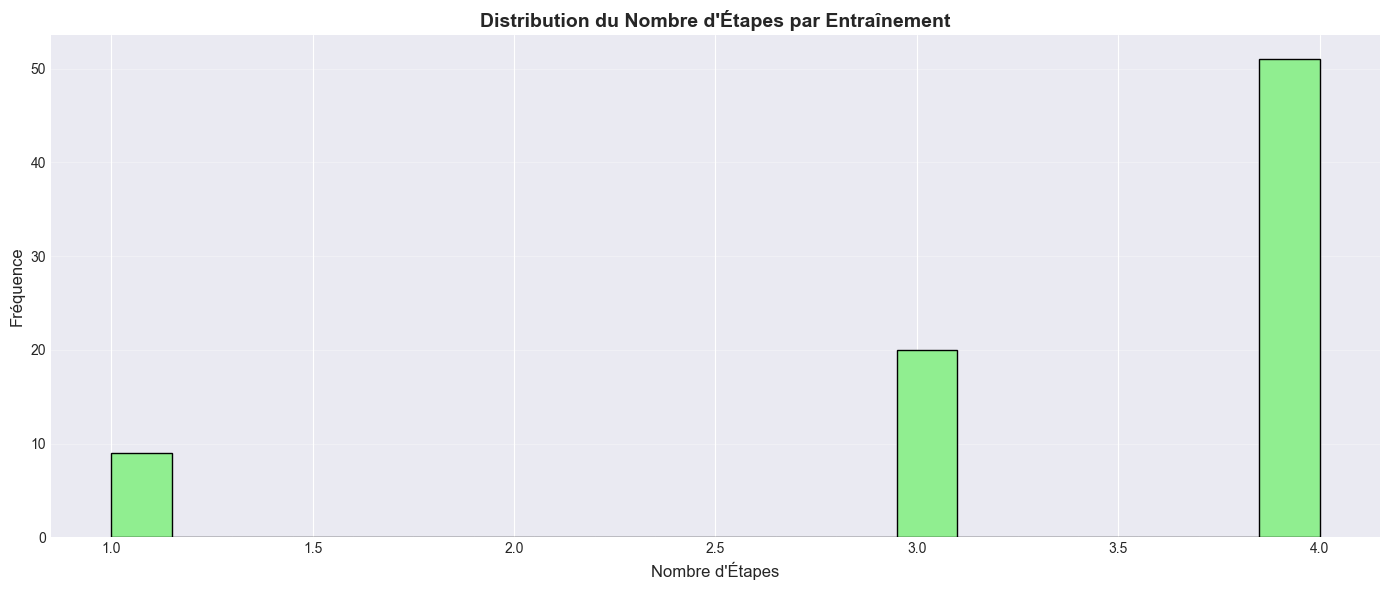


Top 10 entraînements avec le plus d'étapes:
EntrainementID
Départs au galop                                4
Transitions au trot et au pas                   4
Serpentine (3B) au trot                         4
Serpentine (3B) au galop/Contre galop           4
Serpentine (3B) au galop/changement de pieds    4
Serpentine (4B) au trot                         4
Serpentine (4B) au galop/contre galop           4
Serpentine (4B) au galop/changement de pieds    4
Epaule en dedans au pas                         4
Epaule en dedans au trot                        4
dtype: int64


In [46]:
# Analyse des relations entre Entrainement et EtapeEntrainement
if 'entrainement' in dataframes and 'etape_entrainement' in dataframes:
    df_ent = dataframes['entrainement']
    df_etape = dataframes['etape_entrainement']
    
    print("RELATION ENTRE ENTRAINEMENT ET ETAPE ENTRAINEMENT")
    print("="*80)
    
    # Vérifier les colonnes de clé étrangère
    if 'EntrainementID' in df_etape.columns:
        # Compter les étapes par entraînement
        etapes_par_entrainement = df_etape.groupby('EntrainementID').size()
        
        print(f"Nombre d'entraînements avec étapes: {len(etapes_par_entrainement)}")
        print(f"Nombre moyen d'étapes par entraînement: {etapes_par_entrainement.mean():.2f}")
        print(f"Nombre min d'étapes: {etapes_par_entrainement.min()}")
        print(f"Nombre max d'étapes: {etapes_par_entrainement.max()}")
        
        # Graphique
        plt.figure(figsize=(14, 6))
        etapes_par_entrainement.hist(bins=20, color='lightgreen', edgecolor='black')
        plt.title("Distribution du Nombre d'Étapes par Entraînement", fontsize=14, fontweight='bold')
        plt.xlabel("Nombre d'Étapes", fontsize=12)
        plt.ylabel('Fréquence', fontsize=12)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Top 10 entraînements avec le plus d'étapes
        print("\nTop 10 entraînements avec le plus d'étapes:")
        top_10 = etapes_par_entrainement.nlargest(10)
        top_10_named = top_10.rename(index=lambda x: entrainement_map.get(x, f"Entrainement {x}"))
        print(top_10_named)

### Explications — Nombre d’étapes par entraînement

- Cet histogramme montre combien d’entraînements ont 1 étape, 2 étapes, 3 étapes, etc.
- Utilité : repérer des entraînements potentiellement trop courts (peu d’étapes) ou très détaillés (beaucoup d’étapes).
- Le top 10 affiché juste après est donné avec les **noms d’entraînements** (pas les IDs).

RELATION ENTRE ENTRAINEMENT ET AUDIOFILE
Nombre total de fichiers audio utilisés: 185
Nombre moyen d'utilisations par fichier audio: 42.71

Top 10 fichiers audio les plus utilisés (avec noms):
AudioFileID
Audio 0                                2912
Changer de main                         524
Transition au pas                       389
Départ au trot                          202
Transition au trot                      199
Départ au galop                         196
Piste à main droiter                    158
Marcher au pas à main G                 145
décontraction et extention encolure     143
Piste à main gauche                     122
Name: count, dtype: int64


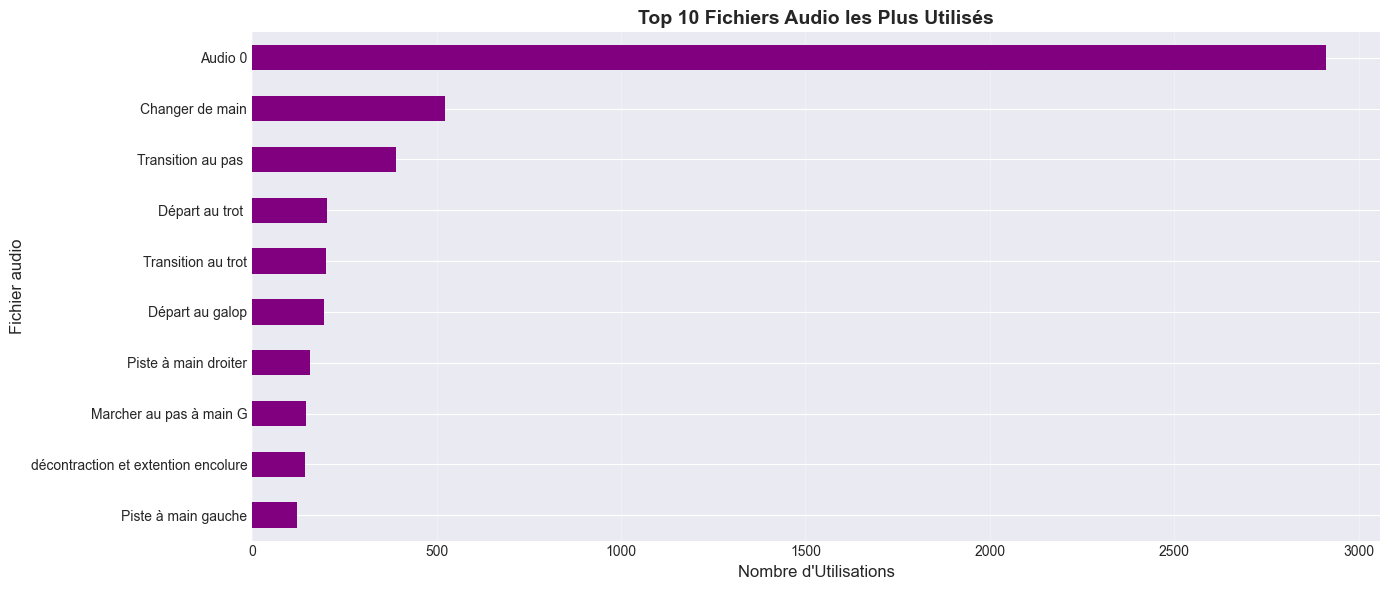

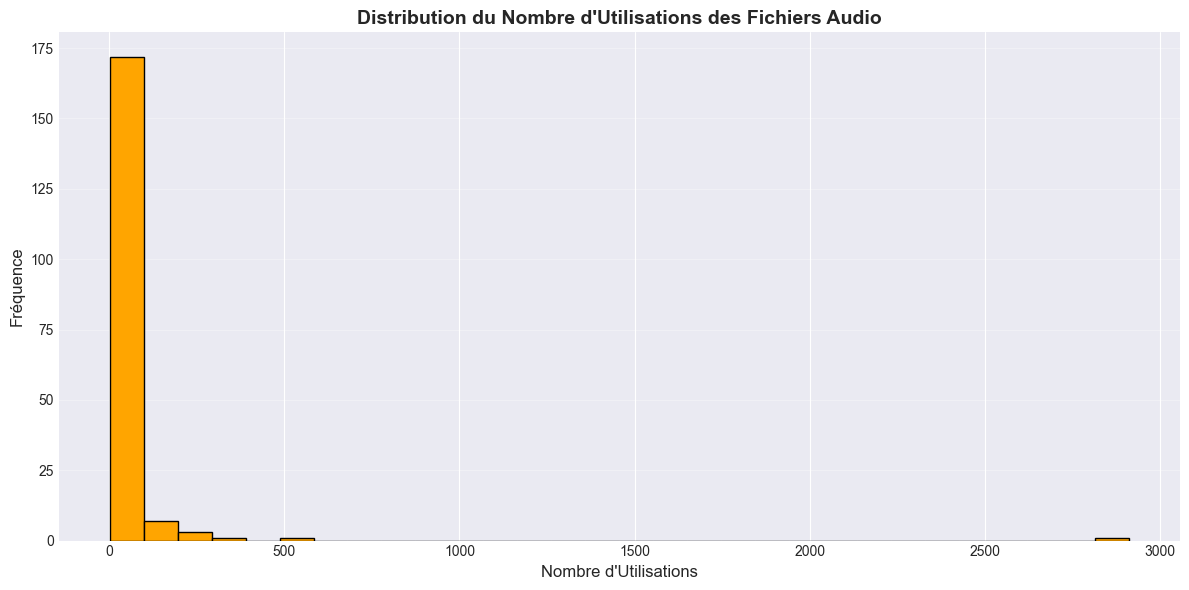

In [47]:
# Analyse de la relation entre Entrainement et AudioFile via Entrainement_Audio
if 'entrainement_audio' in dataframes and 'audiofile' in dataframes:
    df_ent_audio = dataframes['entrainement_audio']
    df_audio = dataframes['audiofile']
    
    print("RELATION ENTRE ENTRAINEMENT ET AUDIOFILE")
    print("="*80)
    
    if 'AudioFileID' in df_ent_audio.columns:
        # Compter l'utilisation de chaque fichier audio
        audio_usage = df_ent_audio['AudioFileID'].value_counts()
        
        print(f"Nombre total de fichiers audio utilisés: {len(audio_usage)}")
        print(f"Nombre moyen d'utilisations par fichier audio: {audio_usage.mean():.2f}")
        
        # Top 10 fichiers audio les plus utilisés (avec noms)
        print("\nTop 10 fichiers audio les plus utilisés (avec noms):")
        top_10_audio = audio_usage.head(10)
        top_10_audio_named = top_10_audio.rename(index=lambda x: audiofile_map.get(x, f"Audio {x}"))
        print(top_10_audio_named)
        
        # Graphique
        plt.figure(figsize=(14, 6))
        top_10_audio_named.plot(kind='barh', color='purple')
        plt.title('Top 10 Fichiers Audio les Plus Utilisés', fontsize=14, fontweight='bold')
        plt.xlabel("Nombre d'Utilisations", fontsize=12)
        plt.ylabel('Fichier audio', fontsize=12)
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Distribution de l'utilisation
        plt.figure(figsize=(12, 6))
        audio_usage.hist(bins=30, color='orange', edgecolor='black')
        plt.title("Distribution du Nombre d'Utilisations des Fichiers Audio", fontsize=14, fontweight='bold')
        plt.xlabel("Nombre d'Utilisations", fontsize=12)
        plt.ylabel('Fréquence', fontsize=12)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

### Explications — Utilisation des fichiers audio

- Le premier graphique montre les **10 audios les plus utilisés** (avec leurs **titres**), pour identifier les ressources audio les plus critiques.
- L’histogramme ensuite montre la **distribution globale** du nombre d’utilisations :
  - un pic sur de petites valeurs signifie beaucoup d’audios peu utilisés,
  - une “longue traîne” indique quelques audios extrêmement utilisés (à prioriser en qualité).

### 4.1 Analyse de la Relation Entrainement - Catégorie

RELATION ENTRE ENTRAINEMENT ET CATEGORIE
Nombre de catégories utilisées: 6

Répartition des entraînements par catégorie (avec noms):
CategorieEntrainementID
EN LONGE          9
DRESSAGE         31
CSO              16
Trotting          3
LONGUES-RÊNES    12
Ethologie         9
Name: count, dtype: int64


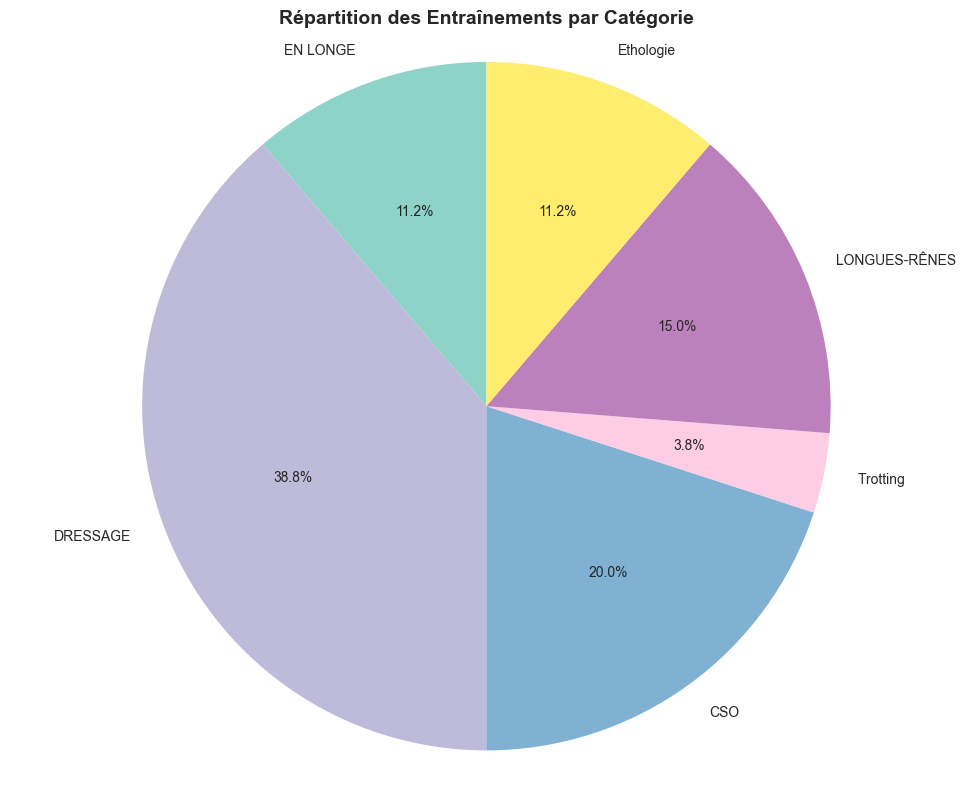

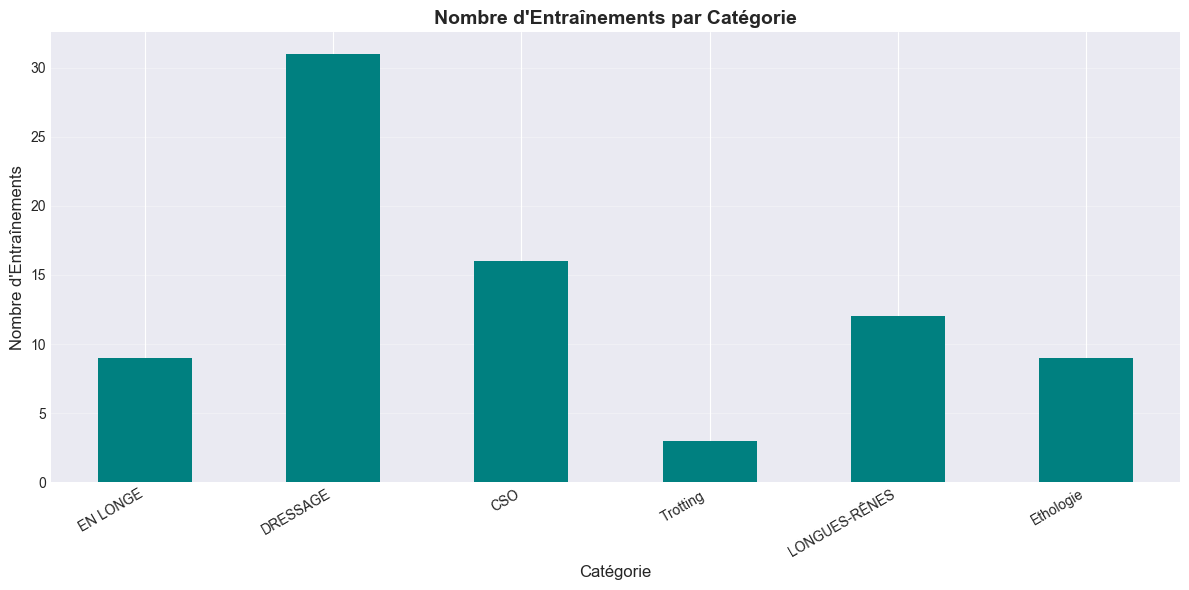

In [48]:
# Jointure entre Entrainement et Catégorie Entrainement
if 'entrainement' in dataframes and 'categorie_entrainement' in dataframes:
    df_ent = dataframes['entrainement']
    df_cat = dataframes['categorie_entrainement']
    
    print("RELATION ENTRE ENTRAINEMENT ET CATEGORIE")
    print("="*80)
    
    # Identifier la clé primaire de catégorie
    cat_id_col = None
    for col in df_cat.columns:
        if 'ID' in col.upper() or 'id' in col.lower():
            cat_id_col = col
            break
    
    if cat_id_col and 'CategorieEntrainementID' in df_ent.columns:
        # Compter les entraînements par catégorie
        ent_par_cat = df_ent['CategorieEntrainementID'].value_counts().sort_index()

        ent_par_cat_named = ent_par_cat.rename(
            index=lambda x: categorie_entrainement_map.get(x, f"Catégorie {x}")
        )
        
        print(f"Nombre de catégories utilisées: {len(ent_par_cat_named)}")
        print(f"\nRépartition des entraînements par catégorie (avec noms):")
        print(ent_par_cat_named)
        
        # Graphique en camembert
        plt.figure(figsize=(10, 8))
        colors = plt.cm.Set3(np.linspace(0, 1, len(ent_par_cat_named)))
        plt.pie(ent_par_cat_named.values, labels=list(ent_par_cat_named.index), 
                autopct='%1.1f%%', startangle=90, colors=colors)
        plt.title('Répartition des Entraînements par Catégorie', fontsize=14, fontweight='bold')
        plt.axis('equal')
        plt.tight_layout()
        plt.show()
        
        # Graphique en barres
        plt.figure(figsize=(12, 6))
        ent_par_cat_named.plot(kind='bar', color='teal')
        plt.title("Nombre d'Entraînements par Catégorie", fontsize=14, fontweight='bold')
        plt.xlabel('Catégorie', fontsize=12)
        plt.ylabel("Nombre d'Entraînements", fontsize=12)
        plt.xticks(rotation=30, ha='right')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

### Explications — Répartition des entraînements par catégorie

- Le camembert montre la **part (%)** de chaque catégorie d’entraînement.
- Le graphique en barres montre les **volumes exacts** (plus précis pour comparer).
- Les libellés affichés sont les **noms de catégories** (issus du mapping), afin que l’entreprise puisse interpréter sans consulter la base.

### 4.2 Analyse de la Relation Entrainement - Matériel

**Explication :** Cette section analyse quels matériels sont utilisés dans quels entraînements. Cela permet de comprendre :
- Quels matériels sont les plus populaires
- Combien de matériels sont nécessaires en moyenne par entraînement
- La distribution de l'utilisation des matériels

**Enjeux pour l'entreprise :**
- **Gestion des stocks** : identifier les matériels les plus utilisés pour s'assurer qu'ils sont toujours disponibles
- **Planification** : comprendre quels entraînements nécessitent le plus de matériel
- **Optimisation** : identifier les matériels sous-utilisés ou sur-utilisés

RELATION ENTRE ENTRAINEMENT ET MATERIEL
Nombre total de relations entraînement-matériel: 689

Colonnes disponibles: ['N° Enr.', 'MaterielEntrainementID', 'EntrainementID', 'Name', 'Photo', 'MaterielID']

STATISTIQUES SUR L'UTILISATION DES MATÉRIELS:
  - Nombre d'entraînements utilisant du matériel: 82
  - Nombre moyen de matériels par entraînement: 8.40
  - Nombre minimum de matériels: 1
  - Nombre maximum de matériels: 11


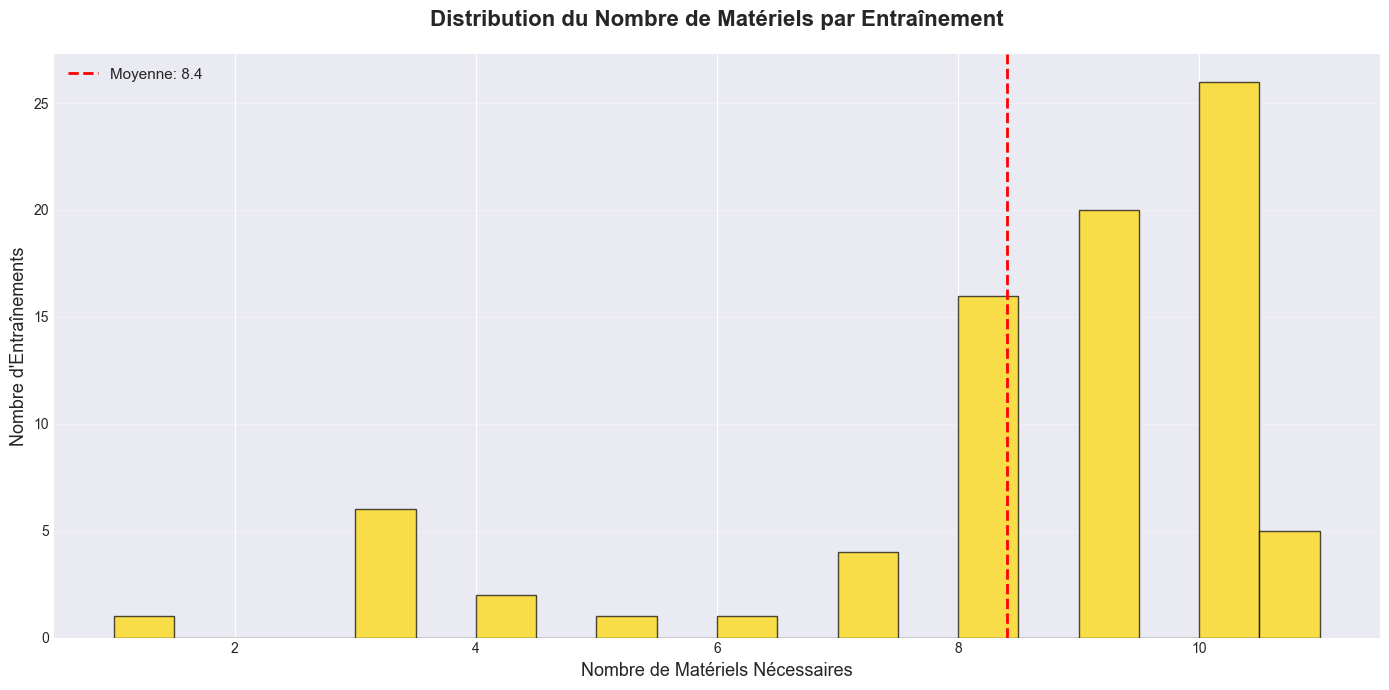


TOP 15 MATÉRIELS LES PLUS UTILISÉS (avec noms):
  Gants d'équitation: 74 utilisations
  Cloches: 70 utilisations
  Guêtres : 70 utilisations
  Tapis de selle : 70 utilisations
  Filet: 64 utilisations
  Casque d'équitation: 50 utilisations
  Bottes d'équitation: 50 utilisations
  Barres: 36 utilisations
  Stick de dressage: 32 utilisations
  Selle de dressage: 32 utilisations
  Surfaix: 21 utilisations
  Cônes: 17 utilisations
  Sangle bavette: 16 utilisations
  Selle d'obstacle: 15 utilisations
  Longues-rênes: 12 utilisations


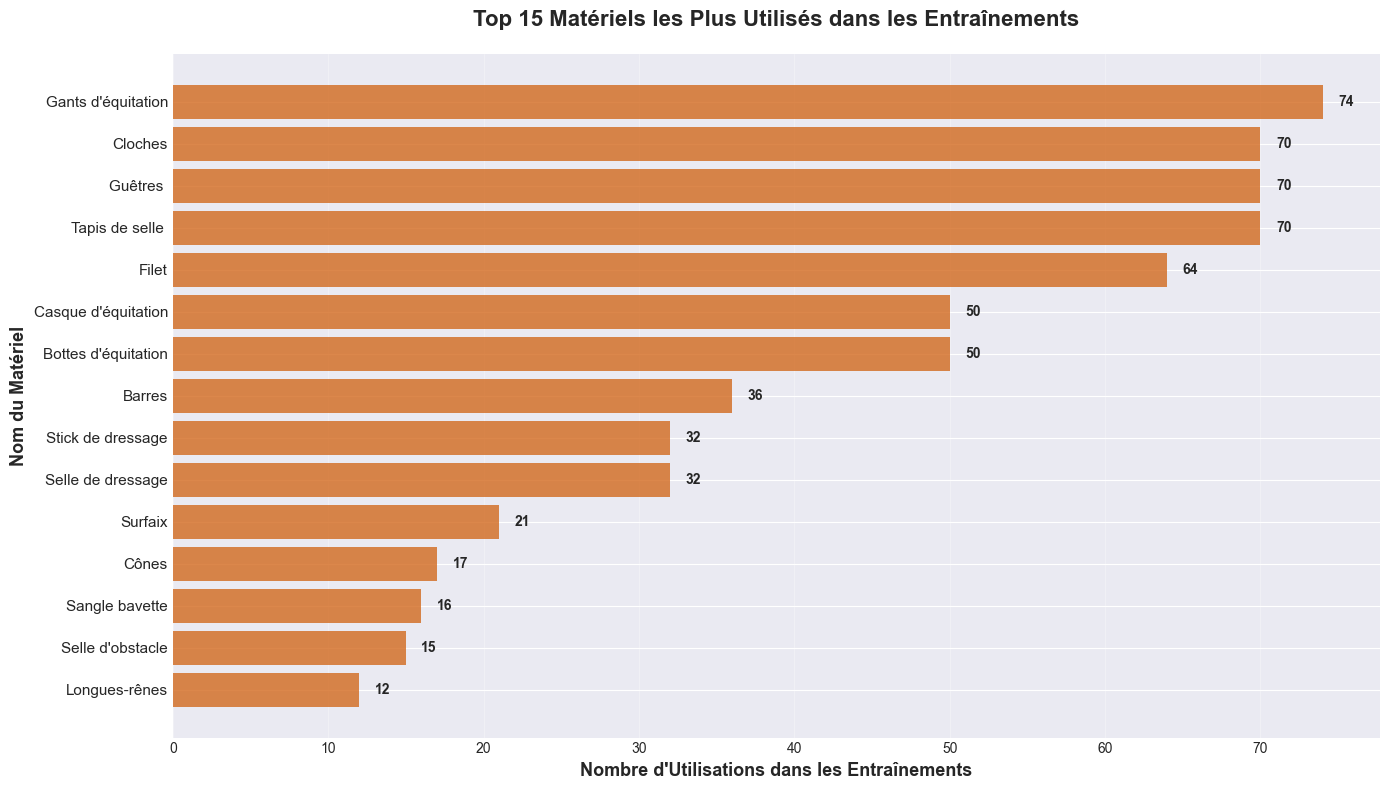


ANALYSE DÉTAILLÉE: Matériels par Entraînement

Exemples d'entraînements avec leurs matériels:

  1. Aborder un double vertical / oxer:
     Matériels nécessaires (11): Bottes d'équitation, Gants d'équitation, Guêtres , Selle d'obstacle, Tapis de selle , Casque d'équitation, Filet, Sangle bavette
     ... et 3 autres matériels

  2. Appuyer au galop:
     Matériels nécessaires (9): Bottes d'équitation, Gants d'équitation, Selle de dressage, Stick de dressage, Guêtres , Tapis de selle , Casque d'équitation, Filet
     ... et 1 autres matériels

  3. Appuyer au pas :
     Matériels nécessaires (9): Bottes d'équitation, Gants d'équitation, Selle de dressage, Stick de dressage, Guêtres , Tapis de selle , Casque d'équitation, Filet
     ... et 1 autres matériels

  4. Appuyer au trot:
     Matériels nécessaires (9): Bottes d'équitation, Gants d'équitation, Selle de dressage, Stick de dressage, Guêtres , Tapis de selle , Casque d'équitation, Filet
     ... et 1 autres matériels

  5. Augment

,N° Enr.,MaterielEntrainementID,EntrainementID,Name,Photo,MaterielID
0,1,1,1,LONGE,None,0
1,11,355,3,None,None,27
2,10,356,3,None,None,164
3,9,357,3,None,None,277
4,8,358,3,None,None,161
5,7,359,3,None,None,185
6,6,360,3,None,None,54
7,5,361,3,None,None,116
8,4,362,3,None,None,59
9,3,363,3,None,None,61


In [49]:
# Analyse de la relation entre Entrainement et Matériel avec noms au lieu d'IDs
if 'materiel_entrainement' in dataframes:
    df_mat_ent = dataframes['materiel_entrainement']
    
    print("RELATION ENTRE ENTRAINEMENT ET MATERIEL")
    print("="*80)
    print(f"Nombre total de relations entraînement-matériel: {len(df_mat_ent)}")
    print(f"\nColonnes disponibles: {list(df_mat_ent.columns)}")
    
    # Identifier les colonnes de clés étrangères
    ent_id_col = None
    mat_id_col = None
    
    for col in df_mat_ent.columns:
        if 'ENTRAINEMENTID' in col.upper():
            ent_id_col = col
        if 'MATERIELID' in col.upper():
            mat_id_col = col
    
    if ent_id_col:
        mat_par_ent = df_mat_ent[ent_id_col].value_counts()
        print(f"\nSTATISTIQUES SUR L'UTILISATION DES MATÉRIELS:")
        print(f"  - Nombre d'entraînements utilisant du matériel: {len(mat_par_ent)}")
        print(f"  - Nombre moyen de matériels par entraînement: {mat_par_ent.mean():.2f}")
        print(f"  - Nombre minimum de matériels: {mat_par_ent.min()}")
        print(f"  - Nombre maximum de matériels: {mat_par_ent.max()}")
        
        # Graphique avec explication
        plt.figure(figsize=(14, 7))
        mat_par_ent.hist(bins=20, color='gold', edgecolor='black', alpha=0.7)
        plt.title('Distribution du Nombre de Matériels par Entraînement', 
                 fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Nombre de Matériels Nécessaires', fontsize=13)
        plt.ylabel("Nombre d'Entraînements", fontsize=13)
        plt.grid(axis='y', alpha=0.3)
        plt.axvline(mat_par_ent.mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Moyenne: {mat_par_ent.mean():.1f}')
        plt.legend(fontsize=11)
        plt.tight_layout()
        plt.show()
    
    if mat_id_col and 'materiel' in dataframes:
        # Compter les utilisations par matériel avec les noms
        ent_par_mat = df_mat_ent[mat_id_col].value_counts()
        
        # Créer un DataFrame avec les noms des matériels
        materiel_usage_df = pd.DataFrame({
            'MaterielID': ent_par_mat.index,
            'Nombre_Utilisations': ent_par_mat.values
        })
        
        # Ajouter les noms des matériels
        materiel_usage_df['Nom_Materiel'] = materiel_usage_df['MaterielID'].map(
            lambda x: materiel_map.get(x, f'Matériel ID {x} (nom non trouvé)')
        )
        
        # Trier par nombre d'utilisations
        materiel_usage_df = materiel_usage_df.sort_values('Nombre_Utilisations', ascending=False)
        
        print(f"\nTOP 15 MATÉRIELS LES PLUS UTILISÉS (avec noms):")
        print("="*80)
        for idx, row in materiel_usage_df.head(15).iterrows():
            print(f"  {row['Nom_Materiel']}: {row['Nombre_Utilisations']} utilisations")
        
        # Graphique avec noms
        plt.figure(figsize=(14, 8))
        top_15 = materiel_usage_df.head(15)
        bars = plt.barh(range(len(top_15)), top_15['Nombre_Utilisations'], color='chocolate', alpha=0.8)
        plt.yticks(range(len(top_15)), top_15['Nom_Materiel'], fontsize=11)
        plt.xlabel("Nombre d'Utilisations dans les Entraînements", fontsize=13, fontweight='bold')
        plt.ylabel('Nom du Matériel', fontsize=13, fontweight='bold')
        plt.title('Top 15 Matériels les Plus Utilisés dans les Entraînements', 
                 fontsize=16, fontweight='bold', pad=20)
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        
        # Ajouter les valeurs sur les barres
        for i, (idx, row) in enumerate(top_15.iterrows()):
            plt.text(row['Nombre_Utilisations'] + 1, i, str(int(row['Nombre_Utilisations'])), 
                    va='center', fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Analyse détaillée : matériels par entraînement avec noms
        if ent_id_col and 'entrainement' in dataframes:
            print(f"\nANALYSE DÉTAILLÉE: Matériels par Entraînement")
            print("="*80)
            
            # Créer un DataFrame enrichi avec noms
            df_enriched = df_mat_ent.copy()
            df_enriched['Nom_Entrainement'] = df_enriched[ent_id_col].map(entrainement_map)
            df_enriched['Nom_Materiel'] = df_enriched[mat_id_col].map(materiel_map)
            
            # Grouper par entraînement
            entrainement_materiels = df_enriched.groupby('Nom_Entrainement')['Nom_Materiel'].apply(list).to_dict()
            
            print(f"\nExemples d'entraînements avec leurs matériels:")
            for i, (ent_nom, materiels) in enumerate(list(entrainement_materiels.items())[:5]):
                if ent_nom and 'non trouvé' not in str(ent_nom):
                    materiels_noms = [m for m in materiels if m and 'non trouvé' not in str(m)]
                    print(f"\n  {i+1}. {ent_nom}:")
                    print(f"     Matériels nécessaires ({len(materiels_noms)}): {', '.join(materiels_noms[:8])}")
                    if len(materiels_noms) > 8:
                        print(f"     ... et {len(materiels_noms) - 8} autres matériels")
    
    display(df_mat_ent.head(10))

### Explications — Relation Entraînement / Matériel

- Le premier histogramme montre **combien de matériels différents** sont requis par entraînement (avec une ligne rouge = moyenne).
- Le second graphique (barres horizontales) liste les **15 matériels les plus utilisés**, en affichant directement les **noms** (pas les IDs).
- Utilité : aider l’entreprise à identifier les matériels critiques à avoir en stock et les entraînements les plus “coûteux” en logistique.

## 5. Analyse des Durées et Temps

Analysons les durées et temps associés aux entraînements.

In [50]:
if 'entrainement' in dataframes:
    df_ent = dataframes['entrainement']
    
    print("ANALYSE DES DURÉES ET TEMPS")
    print("="*80)
    
    # Chercher les colonnes liées au temps
    time_cols = [col for col in df_ent.columns if any(keyword in col.lower() 
                for keyword in ['duree', 'temps', 'time', 'duration'])]
    
    print(f"Colonnes liées au temps trouvées: {time_cols}")
    
    for col in time_cols:
        print(f"\nAnalyse de la colonne '{col}':")
        print(df_ent[col].describe())
        
        # Essayer de convertir en numérique si possible
        if df_ent[col].dtype == 'object':
            # Essayer d'extraire des nombres
            try:
                # Si c'est au format HHMM (ex: 0128 = 1h28)
                if df_ent[col].str.len().max() == 4:
                    # Convertir en minutes
                    def convert_to_minutes(val):
                        if pd.isna(val) or val == '':
                            return np.nan
                        val_str = str(val).zfill(4)
                        hours = int(val_str[:2])
                        minutes = int(val_str[2:])
                        return hours * 60 + minutes
                    
                    df_ent[f'{col}_minutes'] = df_ent[col].apply(convert_to_minutes)
                    
                    plt.figure(figsize=(12, 6))
                    df_ent[f'{col}_minutes'].hist(bins=30, color='steelblue', edgecolor='black')
                    plt.title(f'Distribution de {col} (en minutes)', fontsize=14, fontweight='bold')
                    plt.xlabel('Durée (minutes)', fontsize=12)
                    plt.ylabel('Fréquence', fontsize=12)
                    plt.grid(axis='y', alpha=0.3)
                    plt.tight_layout()
                    plt.show()
                    
                    print(f"Moyenne: {df_ent[f'{col}_minutes'].mean():.2f} minutes")
                    print(f"Médiane: {df_ent[f'{col}_minutes'].median():.2f} minutes")
            except Exception:
                pass

ANALYSE DES DURÉES ET TEMPS
Colonnes liées au temps trouvées: ['Duree', 'TempsPrep', 'TempsMiseEnPlace', 'TempsEchauffement', 'TempsTravail', 'TempsRecuperation', 'TempsSoins']

Analyse de la colonne 'Duree':
count           80
unique          11
top       01:20:00
freq            28
Name: Duree, dtype: object

Analyse de la colonne 'TempsPrep':
count    80.00000
mean     13.11250
std       2.40776
min      10.00000
25%      10.00000
50%      15.00000
75%      15.00000
max      15.00000
Name: TempsPrep, dtype: float64

Analyse de la colonne 'TempsMiseEnPlace':
count    80.000000
mean      4.325000
std       4.434545
min       0.000000
25%       0.000000
50%       5.000000
75%      10.000000
max      15.000000
Name: TempsMiseEnPlace, dtype: float64

Analyse de la colonne 'TempsEchauffement':
count    80.000000
mean     14.212500
std       5.642725
min       0.000000
25%      15.000000
50%      15.000000
75%      15.000000
max      23.000000
Name: TempsEchauffement, dtype: float64

Analy

### Explications — Analyse des durées et temps

- Ces histogrammes montrent la **distribution des durées** (converties en minutes) pour les colonnes détectées (`duree`, `temps`, …).
- Objectif : repérer rapidement des valeurs atypiques (durées très courtes/longues) et comprendre l’ordre de grandeur habituel.
- Les valeurs **moyenne** et **médiane** imprimées juste après aident à résumer la tendance centrale et à voir si la distribution est asymétrique.

## 6. Analyse des Tables Pro (Pro1, Pro2, Pro3, Pro4)

Analysons les tables professionnelles pour comprendre leur structure et relations.

In [51]:
# Analyse des tables Pro
pro_tables = ['pro1', 'pro2', 'pro3', 'pro4']
type_pro_tables = ['type_pro1', 'type_pro2', 'type_pro3']

print("ANALYSE DES TABLES PRO")
print("="*80)

for pro_table in pro_tables:
    if pro_table in dataframes:
        df_pro = dataframes[pro_table]
        print(f"\nTable {pro_table.upper()}:")
        print(f"  - Nombre de lignes: {len(df_pro)}")
        print(f"  - Colonnes: {list(df_pro.columns)}")
        display(df_pro.head())

# Analyse des types Pro
print("\n" + "="*80)
print("ANALYSE DES TABLES TYPE PRO")
print("="*80)

for type_table in type_pro_tables:
    if type_table in dataframes:
        df_type = dataframes[type_table]
        print(f"\nTable {type_table.upper()}:")
        print(f"  - Nombre de lignes: {len(df_type)}")
        print(f"  - Colonnes: {list(df_type.columns)}")
        display(df_type.head())

ANALYSE DES TABLES PRO

Table PRO1:
  - Nombre de lignes: 8196
  - Colonnes: ['N° Enr.', 'ProID', 'TypeProID', 'Adresse', 'CP', 'Ville', 'Pays', 'Nom', 'Desc', 'Tel', 'eMail', 'WebSite', 'Longitude', 'Latitude']


,N° Enr.,ProID,TypeProID,Adresse,CP,Ville,Pays,Nom,Desc,Tel,eMail,WebSite,Longitude,Latitude
0,8855,8855,2,5 Pl Henri Dunant,01200,BELLEGARDE SUR VALSERINE,FRANCE,FOESSEL Véronique,None,04 50 56 65 00,None,None,5.829336,46.107732
1,8856,8856,2,lieudit Bomplein,03160,COUZON,FRANCE,HOUE Johanna,None,06 88 81 09 17,None,None,3.118436,46.657964
2,8857,8857,2,ZI St Christophe,04000,DIGNE LES BAINS,FRANCE,Clinique St Christophe,None,04 92 31 10 36,None,None,6.191778,44.078894
3,8858,8858,2,9 promenade du Cap,06190,ROQUEBRUNE CAP MARTIN,FRANCE,Clinique du Cap Martin,None,04 93 35 41 48,None,None,7.481501,43.757991
4,8859,8859,2,3 r Maurice Mignon,06200,NICE,FRANCE,"CLINIQUE Dr AZRIA, BARRAUD, BROCHOT, CASSAGNES",None,04 93 71 21 41,None,None,7.222486,43.672440



Table PRO2:
  - Nombre de lignes: 240
  - Colonnes: ['N° Enr.', 'ProID', 'TypeProID', 'Adresse', 'CP', 'Ville', 'Pays', 'Nom', 'Desc', 'Tel', 'eMail', 'WebSite', 'Longitude', 'Latitude']


,N° Enr.,ProID,TypeProID,Adresse,CP,Ville,Pays,Nom,Desc,Tel,eMail,WebSite,Longitude,Latitude
0,1,1,1,lieu dit Clos fleuri,01320,CRANS,FRANCE,FERNANDEZ Cyrielle,None,06 22 49 60 62,None,None,5.213426,45.961586
1,2,2,1,733 av de Trevoux,01000,St Denis lesBOURG,FRANCE,CHARLET Karen,None,04 74 21 43 80,None,None,5.197625,46.200260
2,3,3,1,6 bis le Moulin,01320,CHATENAY,FRANCE,TERZIAN Anne-Laure,None,06 18 07 50 69,None,None,1.884111,48.358080
3,4,4,1,39 Porte du Grand Lyon,01700,NEYRON,FRANCE,CLINIQUE Equine du Champ du Perier,None,04 37 85 03 90,None,None,4.925150,45.820590
4,5,5,1,ZI St Christophe,04000,DIGNE LES BAINS,FRANCE,Clinique St Christophe,None,04 92 31 10 36,None,None,6.191778,44.078894



Table PRO3:
  - Nombre de lignes: 1505
  - Colonnes: ['N° Enr.', 'ProID', 'TypeProID', 'Adresse', 'CP', 'Ville', 'Pays', 'Nom', 'Desc', 'Tel', 'eMail', 'WebSite', 'Longitude', 'Latitude', 'TypeProID1', 'TypeProID2']


...

,N° Enr.,TypeProID,Type
0,1,1,Centre équestre
1,2,2,Dentistes Equins
2,3,3,Elevage de chevaux
3,4,4,Maréchal Ferrant
4,5,5,Ostéopathes Equins



Table TYPE_PRO2:
  - Nombre de lignes: 1
  - Colonnes: ['N° Enr.', 'TypeProID', 'Type']


,N° Enr.,TypeProID,Type
0,1,1,Vétérinaires Equins



Table TYPE_PRO3:
  - Nombre de lignes: 1
  - Colonnes: ['N° Enr.', 'TypeProID', 'Type']


,N° Enr.,TypeProID,Type
0,1,1,Ecuries de propriétaires


## 7. Analyse de la Table Medical

In [52]:
if 'medical' in dataframes:
    df_medical = dataframes['medical']
    
    print("ANALYSE DE LA TABLE MEDICAL")
    print("="*80)
    print(f"Nombre total d'enregistrements médicaux: {len(df_medical)}")
    print(f"\nColonnes disponibles: {list(df_medical.columns)}")
    
    display(df_medical.head(10))
    
    # Statistiques descriptives
    numeric_cols = df_medical.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        print("\nStatistiques numériques:")
        print(df_medical[numeric_cols].describe())
    
    # Analyse des valeurs manquantes
    print("\nValeurs manquantes:")
    missing = df_medical.isnull().sum()
    print(missing[missing > 0])

ANALYSE DE LA TABLE MEDICAL
Nombre total d'enregistrements médicaux: 8

Colonnes disponibles: ['N° Enr.', 'MedicalID', 'Name', 'Primo']


,N° Enr.,MedicalID,Name,Primo
0,1,1,Vaccin Grippe,1
1,2,2,Vaccin Rhinopneumonie,1
2,3,3,Vaccin Arterite virale,1
3,4,4,Vaccin Maladie du west nile,1
4,5,5,Marechalerie (derniere visite),0
5,6,6,Dentiste equin (derniere visite),0
6,7,7,Ostéopathe (derniere visite),0
7,8,8,Mancure,0



Statistiques numériques:
       N° Enr.  MedicalID     Primo
count  8.00000    8.00000  8.000000
mean   4.50000    4.50000  0.500000
std    2.44949    2.44949  0.534522
min    1.00000    1.00000  0.000000
25%    2.75000    2.75000  0.000000
50%    4.50000    4.50000  0.500000
75%    6.25000    6.25000  1.000000
max    8.00000    8.00000  1.000000

Valeurs manquantes:
Series([], dtype: int64)


## 8. Conclusions et Insights

### Résumé des Principales Découvertes:

1. **Structure de la Base de Données**: La base de données contient plusieurs tables Excel liées à l'entraînement équestre, avec des relations complexes entre les entraînements, les étapes, les références aux fichiers audio (via IDs), le matériel et les catégories.

2. **Relations Clés**:
   - Les entraînements sont organisés en catégories
   - Chaque entraînement contient plusieurs étapes
   - Les étapes sont associées à des fichiers audio (via les IDs dans les tables Excel)
   - Les entraînements nécessitent du matériel spécifique

3. **Analyse Excel uniquement**: Cette analyse se concentre uniquement sur les données des fichiers Excel, sans inclure les fichiers multimédias (images, audio) qui peuvent être référencés dans les tables.

4. **Tables Professionnelles**: Les tables Pro1-4 semblent contenir des données professionnelles spécifiques qui nécessitent une analyse plus approfondie selon le contexte métier.

### Recommandations:

- Vérifier l'intégrité référentielle entre les tables
- Analyser plus en détail les durées et difficultés des entraînements
- Explorer les patterns d'utilisation des fichiers audio
- Examiner les relations entre matériel et types d'entraînements

In [53]:
# Création d'un DataFrame de synthèse pour export
summary_data = []
for name, df in dataframes.items():
    summary_data.append({
        'Table': name,
        'Lignes': len(df),
        'Colonnes': len(df.columns),
        'Valeurs Manquantes': df.isnull().sum().sum(),
        'Complétude (%)': round((1 - df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100, 2),
        'Colonnes Numériques': len(df.select_dtypes(include=[np.number]).columns),
        'Colonnes Textuelles': len(df.select_dtypes(include=['object']).columns)
    })

summary_export = pd.DataFrame(summary_data)
summary_export = summary_export.sort_values('Lignes', ascending=False)

print("TABLEAU DE SYNTHÈSE COMPLET")
print("="*80)
display(summary_export)

# Option pour exporter en CSV
# summary_export.to_csv('resume_analyse_ekwo_db.csv', index=False)
# print("\nRésumé exporté dans 'resume_analyse_ekwo_db.csv'")

TABLEAU DE SYNTHÈSE COMPLET


,Table,Lignes,Colonnes,Valeurs Manquantes,Complétude (%),Colonnes Numériques,Colonnes Textuelles
11,pro1,8196,14,20473,82.16,5,9
6,entrainement_audio,7902,7,0,100.00,7,0
13,pro3,1505,16,5807,75.88,7,9
14,pro4,1484,16,3594,84.86,7,9
3,description_entrainement,811,8,1622,75.00,3,1
9,materiel_entrainement,689,6,1377,66.69,4,2
7,etape_entrainement,273,5,6,99.56,4,1
12,pro2,240,14,720,78.57,5,9
0,audiofile,190,5,190,80.00,3,2
5,entrainement,80,15,80,93.33,11,4


### Explications — Tableau de synthèse complet

- Ce tableau récapitule **chaque table** (lignes/colonnes, valeurs manquantes, complétude, colonnes numériques vs textuelles).
- Il sert à repérer rapidement :
  - quelles tables sont les plus volumineuses,
  - lesquelles ont le plus de données manquantes,
  - et où se trouvent les contenus textuels importants (souvent à valider/relire).

ANALYSE DES DESCRIPTIONS — VERSION CORRIGÉE

Table: DESCRIPTION_ENTRAINEMENT
--------------------------------------------------------------------------------
Nombre total d'enregistrements: 811
Colonnes disponibles: ['N° Enr.', 'DescEntrainementID', 'EtapeEntrainementID', 'OrdreNum', 'Type', 'Titre', 'Texte', 'Photo']
Colonnes textuelles analysées: ['Titre', 'Texte']
  - Titre: 156 valeurs non nulles sur 811
    Longueur moyenne: 18.89 caractères
    Longueur max: 48 caractères
  - Texte: 655 valeurs non nulles sur 811
    Longueur moyenne: 163.11 caractères
    Longueur max: 1545 caractères


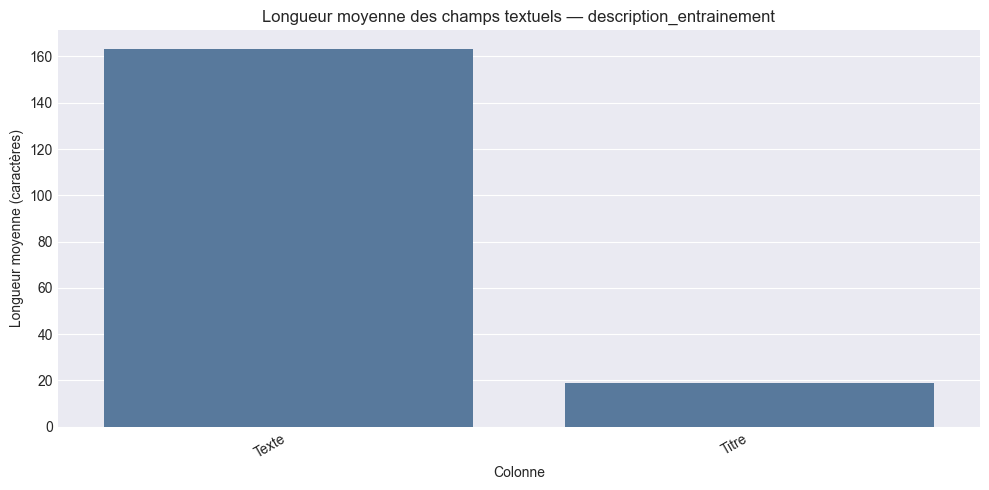

,N° Enr.,DescEntrainementID,EtapeEntrainementID,OrdreNum,Type,Titre,Texte,Photo
0,1,1,1,0,1,COMMENT FIXER LA LONGE,<NA>,None
1,2,2,1,1,3,<NA>,Enlever les les blablablabla,None
2,3,3,1,2,2,ALLIANCE DE LONGE,<NA>,None
3,4,4,1,3,3,<NA>,Fixer les extremeités:....,None
4,5,6,1,4,6,<NA>,fjgjfjf,None
5,6,7,2,0,6,<NA>,Rappel : le mécanisme du galop est une allure ...,None
6,7,8,2,1,5,<NA>,On distingue le galop à droite : \nEn fait le ...,None
7,8,9,2,2,6,<NA>,Les aides : Pour un départ à gauche : Jambe ga...,None
8,10,11,4,0,5,<NA>,Commencer par des départs sur une courbe à mai...,None
9,11,12,4,1,6,<NA>,Dans les angles votre cheval est mieux encadré...,None





Table: DESCRIPTION_FIRST_TIME
--------------------------------------------------------------------------------
Nombre total d'enregistrements: 70
Colonnes disponibles: ['N° Enr.', 'DescFirstTimeID', 'CategorieEntrainementID', 'OrdreNum', 'Type', 'Titre', 'Texte', 'Photo']
Colonnes textuelles analysées: ['Titre', 'Texte']
  - Titre: 27 valeurs non nulles sur 70
    Longueur moyenne: 22.04 caractères
    Longueur max: 46 caractères
  - Texte: 43 valeurs non nulles sur 70
    Longueur moyenne: 156.42 caractères
    Longueur max: 829 caractères


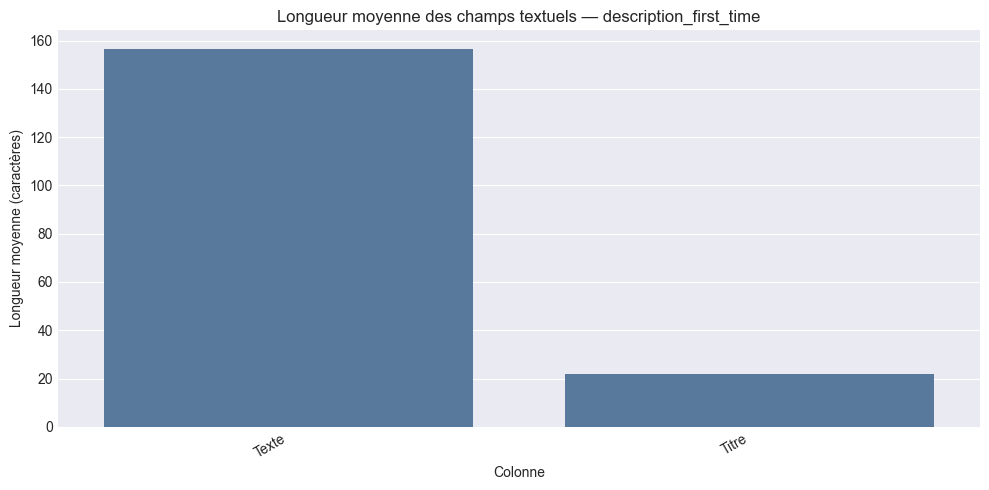

,N° Enr.,DescFirstTimeID,CategorieEntrainementID,OrdreNum,Type,Titre,Texte,Photo
0,1,3,13,0,1,Comment fixer les longues-rênes?,<NA>,None
1,2,4,13,1,3,<NA>,Enlever les rênes de votre filet et mettez-le ...,None
2,3,5,13,2,4,4 positions pour fixer les longues-rênes,<NA>,None
3,4,6,13,3,1,Votre position,<NA>,None
4,5,7,13,4,3,<NA>,Aux longues rênes vous accompagnez votre cheva...,None
5,6,8,1,0,1,Comment fixer la longe?,<NA>,None
6,7,9,1,1,4,Longe,<NA>,None
7,8,11,1,2,5,<NA>,Enlever les rênes de votre filet et mettez-le ...,None
8,9,12,1,3,3,<NA>,Fixer les extrémités de l'alliance aux anneaux...,None
9,10,13,1,4,6,<NA>,Si vous êtes novices cette manière respecte la...,None


In [54]:
# 8bis. Analyse des Descriptions — Correctif et Visualisation
print("ANALYSE DES DESCRIPTIONS — VERSION CORRIGÉE")
print("="*80)

desc_tables = ['description_entrainement', 'description_first_time']

for desc_table in desc_tables:
    if desc_table in dataframes:
        df_desc = dataframes[desc_table]
        
        print(f"\nTable: {desc_table.upper()}")
        print("-"*80)
        print(f"Nombre total d'enregistrements: {len(df_desc)}")
        print(f"Colonnes disponibles: {list(df_desc.columns)}")

        # Détection robuste des colonnes textuelles
        keywords = ['texte', 'text', 'titre', 'title', 'description']
        explicit_cols = [c for c in df_desc.columns
                         if any(k in c.lower() for k in keywords)
                         and 'id' not in c.lower()]
        if explicit_cols:
            text_cols = explicit_cols
        else:
            text_cols = [c for c in df_desc.select_dtypes(include=['object', 'string']).columns
                         if 'id' not in c.lower() and 'photo' not in c.lower()]

        if text_cols:
            print(f"Colonnes textuelles analysées: {text_cols}")
            stats_rows = []
            for col in text_cols:
                s = df_desc[col].astype('string')
                lengths = s.str.len()
                non_null = s.notna().sum()
                print(f"  - {col}: {non_null} valeurs non nulles sur {len(df_desc)}")
                if non_null > 0:
                    print(f"    Longueur moyenne: {lengths.mean():.2f} caractères")
                    max_len = lengths.max()
                    print(f"    Longueur max: {int(max_len) if pd.notna(max_len) else 0} caractères")
                stats_rows.append({
                    'colonne': col,
                    'longueur_moyenne': float(lengths.mean()) if non_null > 0 else 0.0,
                    'longueur_max': int(lengths.max()) if pd.notna(lengths.max()) else 0
                })
            # Visualisation des longueurs moyennes par colonne
            try:
                stats_df = pd.DataFrame(stats_rows).sort_values('longueur_moyenne', ascending=False)
                plt.figure(figsize=(10, 5))
                sns.barplot(data=stats_df, x='colonne', y='longueur_moyenne', color='#4C78A8')
                plt.title(f"Longueur moyenne des champs textuels — {desc_table}")
                plt.xlabel("Colonne")
                plt.ylabel("Longueur moyenne (caractères)")
                plt.xticks(rotation=30, ha='right')
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"Erreur lors de la visualisation: {e}")
        else:
            print("Aucune colonne textuelle pertinente détectée.")

        display(df_desc.head(10))
        print("\n")

### Explications — Analyse des Descriptions (8bis)

- Ce graphique compare la longueur moyenne des champs textuels (par exemple `Titre`, `Texte`) dans chaque table de descriptions.
- Une longueur moyenne plus élevée indique des contenus textuels plus détaillés, utiles pour la qualité des consignes et du guidage utilisateur.
- Utilisation: si un champ a une longueur très faible, cela peut révéler des descriptions trop courtes à enrichir; si la longueur est très élevée, prévoir de la mise en forme ou un résumé côté application.

### Explications — Résumé global et Tableau de synthèse

- Le bloc « Résumé global » agrège des métriques simples (nombre de tables, total de lignes/colonnes, complétude). Il permet de vérifier rapidement l’ampleur et la qualité globale des données.
- Le « Tableau de synthèse complet » détaille par table la complétude, le nombre de colonnes numériques vs textuelles, etc. Utilisez-le pour prioriser l’amélioration de la qualité des tables les moins complètes et pour repérer celles riches en texte (souvent utiles à documenter et à valider).